#  Import Python Liabraries

In [1]:

import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sb

print("Liabraries import successfully.")

Liabraries import successfully.


#  Data load

In [2]:
df = pd.read_excel("Online Retail.xlsx")
print("File load successfully!")

File load successfully!


#  Data Overview

In [3]:
df.shape

(541909, 8)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 40.0+ MB


In [5]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [6]:
print("Statistical Summary \n", df.describe())

Statistical Summary 
             Quantity                 InvoiceDate      UnitPrice     CustomerID
count  541909.000000                      541909  541909.000000  406829.000000
mean        9.552250  2011-07-04 13:34:57.156386       4.611114   15287.690570
min    -80995.000000         2010-12-01 08:26:00  -11062.060000   12346.000000
25%         1.000000         2011-03-28 11:34:00       1.250000   13953.000000
50%         3.000000         2011-07-19 17:17:00       2.080000   15152.000000
75%        10.000000         2011-10-19 11:27:00       4.130000   16791.000000
max     80995.000000         2011-12-09 12:50:00   38970.000000   18287.000000
std       218.081158                         NaN      96.759853    1713.600303


#  Duplicates

In [7]:
df.duplicated().sum()

np.int64(5268)

In [8]:
df = df.drop_duplicates().copy()
print("Duplicayes remove successfully:", df.shape)

Duplicayes remove successfully: (536641, 8)


#  Categorical Columns

In [9]:
categorical_columns = df.select_dtypes(include = "object").columns
print("Categorical_columns:")
print(categorical_columns)

Categorical_columns:
Index(['InvoiceNo', 'StockCode', 'Description', 'Country'], dtype='str')


C:\Users\A.H Computer\AppData\Local\Temp\ipykernel_4108\2435329297.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include = "object").columns


#  Data Cleaning

In [10]:
df["Country"].value_counts().head(10)

Country
United Kingdom    490300
Germany             9480
France              8541
EIRE                8184
Spain               2528
Netherlands         2371
Belgium             2069
Switzerland         1994
Portugal            1510
Australia           1258
Name: count, dtype: int64

In [11]:
print("negative qunatities: ", (df["Quantity"] < 0).sum())
print("negative prices: ", (df["UnitPrice"] <= 0).sum())


negative qunatities:  10587
negative prices:  2512


In [12]:
df_clean = df[
    (df["Quantity"] > 0) &
    (df["UnitPrice"] > 0)].copy()
print("Original Rows:", len(df))
print("Cleaned rows:", len(df_clean))
    

Original Rows: 536641
Cleaned rows: 524878


In [13]:
df_clean.isnull().sum()

InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     132186
Country             0
dtype: int64

In [14]:
# CustomerID is an identifier, not a continuous numerical variable
# Therefore missing cutomerId are not imputed with mean or median
# the rows are retained because CustomerID is not requried in sales Anaylics.

## Missing Values Analysis and Handling Decisions

This section reports missing-value counts and percentages for every column in both the original deduplicated dataset (`df`) and the cleaned transaction dataset (`df_clean`). Missing `CustomerID` values are not filled with invented IDs. Such transactions remain useful for overall sales analysis, but are excluded from analyses that require identifying individual customers.


In [15]:
# Missing-value report for every column BEFORE transaction filtering
missing_raw = pd.DataFrame({
    "Column": df.columns,
    "Missing Count": df.isna().sum().values,
    "Missing Percentage (%)": (df.isna().mean() * 100).round(2).values,
    "Non-Missing Count": df.notna().sum().values
})

display(missing_raw.sort_values("Missing Count", ascending=False).reset_index(drop=True))


,Column,Missing Count,Missing Percentage (%),Non-Missing Count
0,CustomerID,135037,25.16,401604
1,Description,1454,0.27,535187
2,StockCode,0,0.00,536641
3,InvoiceNo,0,0.00,536641
4,Quantity,0,0.00,536641
5,InvoiceDate,0,0.00,536641
6,UnitPrice,0,0.00,536641
7,Country,0,0.00,536641


In [16]:
# Missing-value report for every column AFTER the existing cleaning step
missing_clean = pd.DataFrame({
    "Column": df_clean.columns,
    "Missing Count": df_clean.isna().sum().values,
    "Missing Percentage (%)": (df_clean.isna().mean() * 100).round(2).values,
    "Non-Missing Count": df_clean.notna().sum().values
})

display(missing_clean.sort_values("Missing Count", ascending=False).reset_index(drop=True))


,Column,Missing Count,Missing Percentage (%),Non-Missing Count
0,CustomerID,132186,25.18,392692
1,InvoiceNo,0,0.00,524878
2,Description,0,0.00,524878
3,StockCode,0,0.00,524878
4,Quantity,0,0.00,524878
5,InvoiceDate,0,0.00,524878
6,UnitPrice,0,0.00,524878
7,Country,0,0.00,524878


In [17]:
# Handling decision for every column that exists in this dataset.
# The default decision is also explicit for columns not listed in the dictionary.
handling_decisions = {
    "InvoiceNo": "Keep valid values; investigate missing values because invoice-level analysis needs an invoice number.",
    "StockCode": "Keep for general sales totals; exclude rows with missing codes from product-level analysis.",
    "Description": "Keep rows for overall sales if other required fields are valid; exclude missing descriptions from product-name rankings.",
    "Quantity": "Rows with non-positive quantities are already excluded by the cleaning step; investigate missing values before quantity analysis.",
    "InvoiceDate": "Keep valid dates; exclude missing/invalid dates only from time-based analysis.",
    "UnitPrice": "Rows with non-positive prices are already excluded by the cleaning step; investigate missing values before revenue analysis.",
    "CustomerID": "Keep missing as Unknown for overall sales analysis; do not invent customer IDs. Exclude missing IDs from customer-specific analysis.",
    "Country": "Keep valid values; if missing, label as Unknown for reporting or exclude from country comparisons, but do not guess the country."
}

decisions_report = pd.DataFrame({
    "Column": df_clean.columns,
    "Missing Count After Cleaning": df_clean.isna().sum().values,
    "Missing Percentage After Cleaning (%)": (df_clean.isna().mean() * 100).round(2).values,
    "Handling Decision": [
        handling_decisions.get(
            col,
            "Review based on the column's purpose; keep if not required, otherwise exclude affected rows from the specific analysis. Do not invent values."
        )
        for col in df_clean.columns
    ]
})

display(decisions_report.sort_values(
    "Missing Count After Cleaning", ascending=False
).reset_index(drop=True))


,Column,Missing Count After Cleaning,Missing Percentage After Cleaning (%),Handling Decision
0,CustomerID,132186,25.18,Keep missing as Unknown for overall sales anal...
1,InvoiceNo,0,0.00,Keep valid values; investigate missing values ...
2,Description,0,0.00,Keep rows for overall sales if other required ...
3,StockCode,0,0.00,Keep for general sales totals; exclude rows wi...
4,Quantity,0,0.00,Rows with non-positive quantities are already ...
5,InvoiceDate,0,0.00,Keep valid dates; exclude missing/invalid date...
6,UnitPrice,0,0.00,Rows with non-positive prices are already excl...
7,Country,0,0.00,"Keep valid values; if missing, label as Unknow..."


In [18]:
# Specific CustomerID summary using the notebook's existing dataframe names
if "CustomerID" in df.columns:
    raw_customer_missing = int(df["CustomerID"].isna().sum())
    raw_customer_pct = (df["CustomerID"].isna().mean() * 100) if len(df) else 0

    print("CustomerID missing values BEFORE transaction filtering")
    print(f"Rows: {len(df):,}")
    print(f"Missing CustomerID: {raw_customer_missing:,} ({raw_customer_pct:.2f}%)")

    clean_customer_missing = int(df_clean["CustomerID"].isna().sum())
    clean_customer_pct = (df_clean["CustomerID"].isna().mean() * 100) if len(df_clean) else 0

    print("\nCustomerID missing values AFTER transaction filtering")
    print(f"Rows: {len(df_clean):,}")
    print(f"Missing CustomerID: {clean_customer_missing:,} ({clean_customer_pct:.2f}%)")
else:
    print("CustomerID column was not found.")


CustomerID missing values BEFORE transaction filtering
Rows: 536,641
Missing CustomerID: 135,037 (25.16%)

CustomerID missing values AFTER transaction filtering
Rows: 524,878
Missing CustomerID: 132,186 (25.18%)


### Explanation of Missing-Value Decisions

- **CustomerID:** Keep missing IDs as missing (interpreted as Unknown in reports). Do not use mean/median or make up customer IDs. Keep these transactions for overall sales metrics when Quantity and UnitPrice are valid. Exclude them only from customer-specific analysis, such as ranking customers or counting known customers.
- **Description:** Do not remove a transaction from all analyses just because its description is missing. Exclude it from product-name rankings where a description is required.
- **InvoiceDate:** A missing or invalid date prevents reliable monthly/daily analysis; exclude such rows from time-based analysis rather than guessing a date.
- **Quantity and UnitPrice:** These are required for quantity/revenue calculations. The existing cleaning step already removes Quantity <= 0 and UnitPrice <= 0. Missing values should be investigated and excluded from calculations that require them if they cannot be recovered.
- **InvoiceNo and StockCode:** These identifiers are required for invoice-level and product-level analysis respectively. Exclude affected rows from those specific analyses if a value is missing and cannot be recovered.
- **Country:** Do not guess missing countries. For country reporting, use an “Unknown” category or exclude missing-country rows from country comparisons.
- **Any other column:** The table above provides a decision for every column present in the dataset. Handle it according to its analytical purpose, and do not fill values with unsupported guesses.

The raw and cleaned reports are both shown so that cleaning does not hide how many missing values were present initially.


In [19]:
df_clean["Year"] = df_clean["InvoiceDate"].dt.year
df_clean["Month"] = df_clean["InvoiceDate"].dt.month
df_clean["MonthName"] = df_clean["InvoiceDate"].dt.month_name()

In [20]:
df_clean["Sales"] = df_clean["Quantity"] * df_clean["UnitPrice"]

In [21]:
df_clean[["Quantity", "UnitPrice", "Sales"]].head()

,Quantity,UnitPrice,Sales
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


#  Outliers

In [32]:
columns_to_check = ["Quantity", "UnitPrice", "Sales"]

# Store outlier results
outlier_results = []

for col in columns_to_check:

    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    # Identify outliers
    outliers = df_clean[
        (df_clean[col] < lower_limit) |
        (df_clean[col] > upper_limit)
    ]

    outlier_results.append({
        "Column": col,
        "Q1": round(Q1, 2),
        "Q3": round(Q3, 2),
        "IQR": round(IQR, 2),
        "Lower Limit": round(lower_limit, 2),
        "Upper Limit": round(upper_limit, 2),
        "Outlier Count": len(outliers),
        "Outlier Percentage (%)": round(
            len(outliers) / len(df_clean) * 100, 2
        )
    })

# Display outlier summary
outlier_summary = pd.DataFrame(outlier_results)

display(outlier_summary)

,Column,Q1,Q3,IQR,Lower Limit,Upper Limit,Outlier Count,Outlier Percentage (%)
0,Quantity,1.00,11.00,10.00,-14.00,26.00,27111,5.17
1,UnitPrice,1.25,4.13,2.88,-3.07,8.45,37827,7.21
2,Sales,3.90,17.70,13.80,-16.80,38.40,42624,8.12


#  Outlier Visualizations

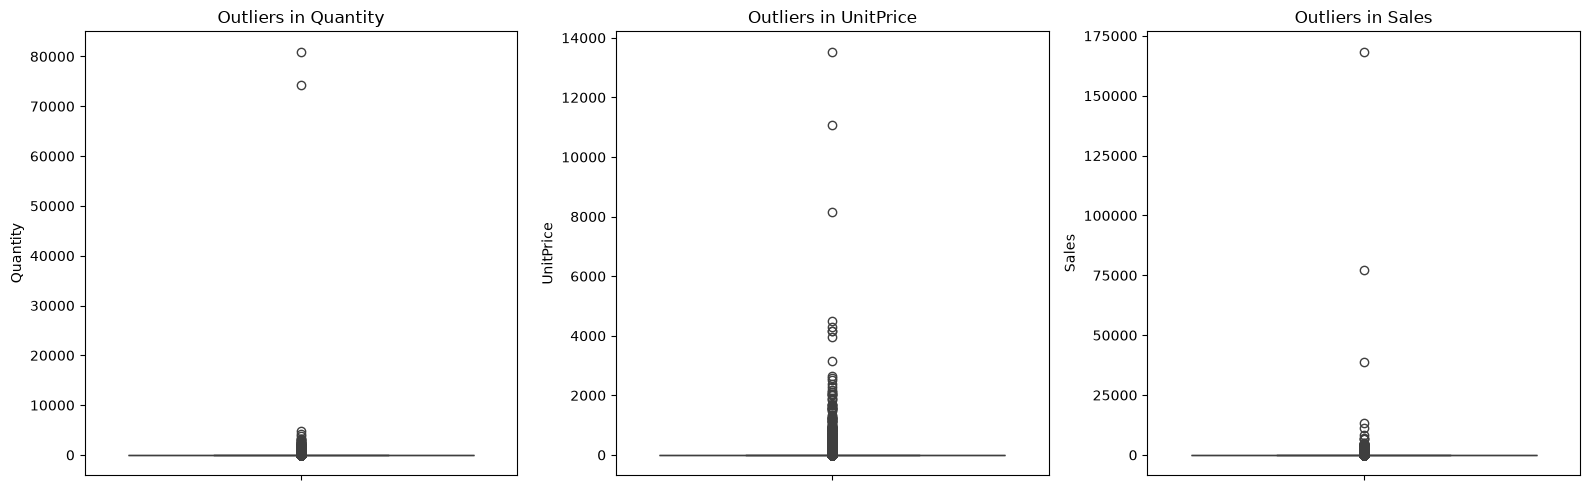

In [34]:

# Boxplots to visualize potential outliers

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, columns_to_check):
    sb.boxplot(y=df_clean[col], ax=ax)
    ax.set_title(f"Outliers in {col}")
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

#  Key Metrices

In [22]:
Total_Sales = df_clean["Sales"].sum()
Average_Sales = df_clean["Sales"].mean()
Total_Transaction = df_clean["InvoiceNo"].nunique()
Total_Products = df_clean["StockCode"].nunique()
Total_Countries = df_clean["Country"].nunique()

print("Total Sales:", round(Total_Sales, 2))
print("Average Sales:", round(Average_Sales, 2))
print("Total_Transaction:", Total_Transaction)
print("Total_Products", Total_Products)
print("Total_Countries", Total_Countries)
      



Total Sales: 10642110.8
Average Sales: 20.28
Total_Transaction: 19960
Total_Products 3922
Total_Countries 38


#  Visuliaztions

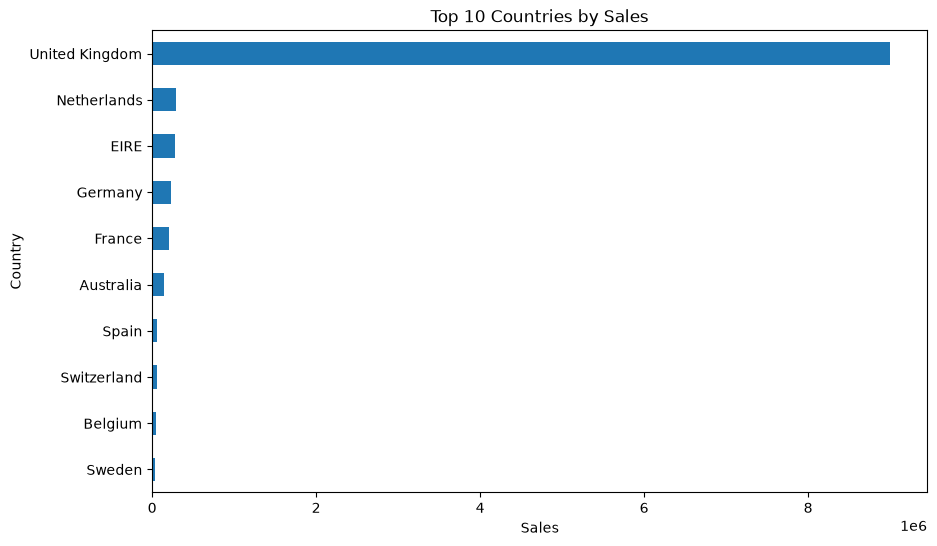

In [23]:
country_sales = (df_clean.groupby("Country")
    ["Sales"]
    .sum()
    .sort_values(ascending =False)
    .head(10)
)

plt.figure(figsize=(10, 6))
country_sales.sort_values().plot(kind = "barh")
plt.title("Top 10 Countries by Sales")
plt.xlabel("Sales")
plt.ylabel("Country")
plt.show()

                                 

#  NON-PRODUCT TRANSACTIONS FILTERING

In [35]:




non_product_codes = [
    "POST",       # Postage
    "DOT",        # Dotcom postage
    "M",          # Manual entry
    "BANK CHARGES",
    "AMAZONFEE",
    "CRUK",
    "D",          # Discount
    "S",          # SAMPLES / other special entries
    "C2",
    "PADS",
    "DCGS",
    "ADJUST",
    "ADJUST2"
]

# Make a copy so df_clean remains unchanged
df_products = df_clean.copy()

# Normalize StockCode for matching
stock_code = (
    df_products["StockCode"]
    .astype("string")
    .str.strip()
    .str.upper()
)

# Filter out known non-product codes
df_products = df_products[
    ~stock_code.isin(non_product_codes)
].copy()

# Keep valid product transactions
df_products = df_products[
    (df_products["Quantity"] > 0) &
    (df_products["UnitPrice"] > 0) &
    (df_products["Description"].notna())
].copy()

# Create Sales if it does not already exist
if "Sales" not in df_products.columns:
    df_products["Sales"] = (
        df_products["Quantity"] * df_products["UnitPrice"]
    )

print("Rows before filtering:", len(df_clean))
print("Rows after product filtering:", len(df_products))
print("Rows excluded:", len(df_clean) - len(df_products))

Rows before filtering: 524878
Rows after product filtering: 522569
Rows excluded: 2309


#  Top 10 Products

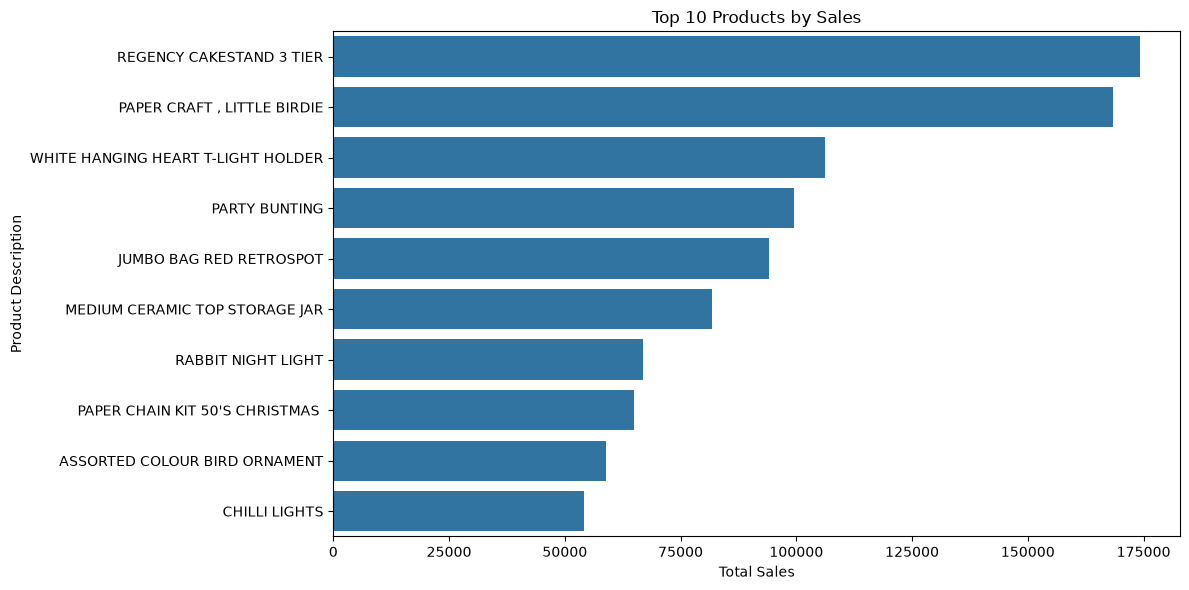

In [37]:




top_products = (
    df_products.groupby("Description")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))

sb.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product Description")
plt.tight_layout()
plt.show()


In [26]:
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])

df_clean["YearMonth"] = df_clean["InvoiceDate"] .dt.to_period("M")

In [27]:
monthly_sales = (df_clean.groupby("YearMonth") ["Sales"].sum().reset_index())

monthly_sales["YearMonth"] = monthly_sales["YearMonth"].astype(str)

monthly_sales.head()

,YearMonth,Sales
0,2010-12,821452.730
1,2011-01,689811.610
2,2011-02,522545.560
3,2011-03,716215.260
4,2011-04,536968.491


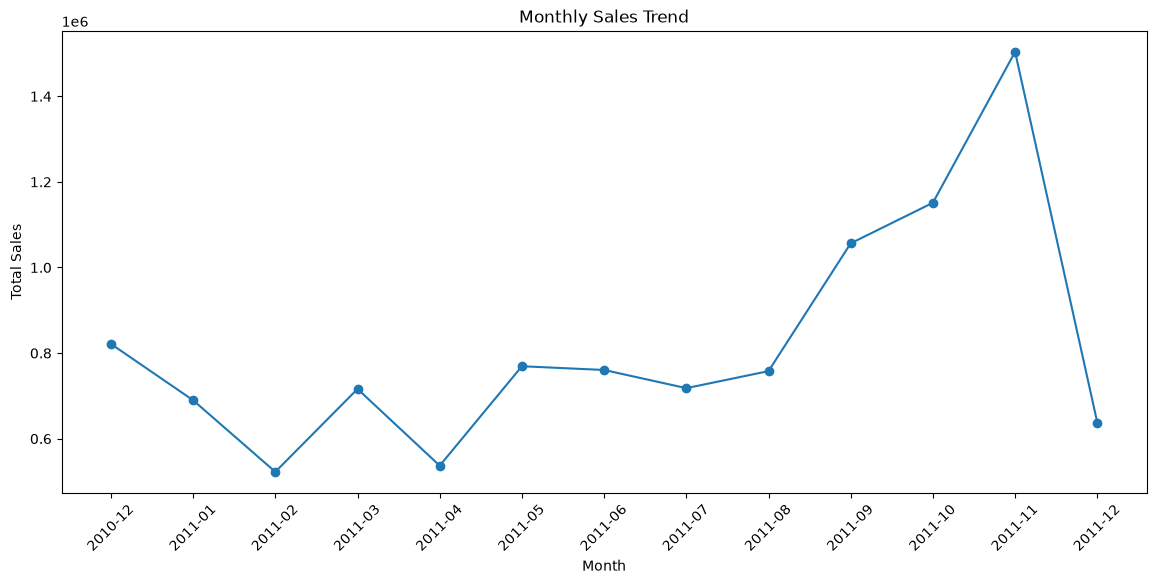

In [28]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales["YearMonth"],
    monthly_sales["Sales"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(False)
plt.show()

In [29]:
sales_statistics =df_clean["Sales"].describe()

sales_statistics

count    524878.000000
mean         20.275399
std         271.693566
min           0.001000
25%           3.900000
50%           9.920000
75%          17.700000
max      168469.600000
Name: Sales, dtype: float64

In [30]:
numeric_column = [
    "Quantity",
    "UnitPrice",
    "Sales"
]

correlation = df_clean[numeric_column].corr()

correlation

,Quantity,UnitPrice,Sales
Quantity,1.000000,-0.003788,0.907402
UnitPrice,-0.003788,1.000000,0.137381
Sales,0.907402,0.137381,1.000000


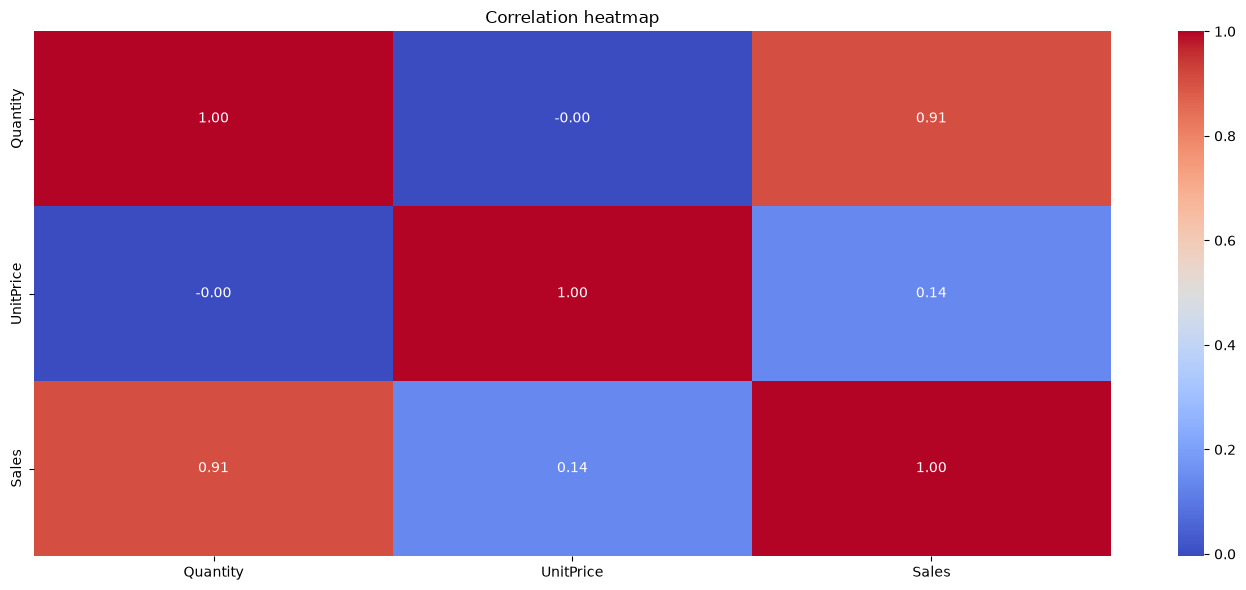

In [31]:
plt.figure(figsize=(14, 6))

sb.heatmap(correlation,
           annot=True,
           fmt=".2f",
           cmap="coolwarm"
          )

plt.title("Correlation heatmap")
plt.tight_layout()
plt.show()